--CNN--

In [6]:
import os
from glob import glob
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold
import joblib

In [16]:
class FreqTemporalCoAttention(layers.Layer):
    """
    A custom layer to learn to focus on important frequency bands and
    time steps within a feature map simultaneously.
    """
    def __init__(self, ratio=8, **kwargs):
        super(FreqTemporalCoAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        # input_shape: (batch, height, width, channels)
        # height ~ frequency, width ~ time
        self.channels = input_shape[-1]
        
        # Neural network for Temporal Attention
        self.temporal_dense1 = layers.Dense(self.channels // self.ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)
        self.temporal_dense2 = layers.Dense(self.channels, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)
        
        # Neural network for Frequency Attention
        self.freq_dense1 = layers.Dense(self.channels // self.ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)
        self.freq_dense2 = layers.Dense(self.channels, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)
        
        super(FreqTemporalCoAttention, self).build(input_shape)

    def call(self, inputs):
        # inputs shape: (batch, freq_bins, time_steps, channels)
        
        # --- Temporal Attention ---
        # Squeeze along the frequency axis -> (batch, time_steps, channels)
        temporal_features = tf.reduce_mean(inputs, axis=1)
        temporal_attention = self.temporal_dense1(temporal_features)
        temporal_attention = self.temporal_dense2(temporal_attention)
        temporal_attention = tf.expand_dims(temporal_attention, axis=1) # (batch, 1, time_steps, channels)

        # --- Frequency Attention ---
        # Squeeze along the time axis -> (batch, freq_bins, channels)
        freq_features = tf.reduce_mean(inputs, axis=2)
        freq_attention = self.freq_dense1(freq_features)
        freq_attention = self.freq_dense2(freq_attention)
        freq_attention = tf.expand_dims(freq_attention, axis=2) # (batch, freq_bins, 1, channels)

        # Recalibrate the original feature map by multiplying with attention weights
        refined_feature_map = inputs * temporal_attention * freq_attention
        
        return refined_feature_map

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config

In [24]:
EMO_DB = False

if EMO_DB:
    EMOTIONS = ['Angry', 'Happy', 'Fear', 'Neutral', 'Sad', 'Boredom', 'Disgust']
    NUM_CLASSES = len(EMOTIONS)
    emotion_map = {
        'Angry': 0, 
        'Happy': 1, 
        'Fear': 2, 
        'Neutral': 3, 
        'Sad': 4, 
        'Boredom': 5, 
        'Disgust': 6
    }
    DATA_PATH = '/kaggle/input/speech-emotion-10/EmoDB/EmoDB'
else:
    EMOTIONS = ['Angry', 'Happy', 'Anxiety', 'Neutral', 'Sad']
    NUM_CLASSES = len(EMOTIONS)
    emotion_map = {
        'Angry': 0, 'Happy': 1, 'Anxiety': 2, 'Neutral': 3, 'Sad': 4
    }
    DATA_PATH = '/kaggle/input/speech-emotion-10/VESC/VESC'

# Actual calculation needed from the data
GLOBAL_MEAN_PITCH = 0.0
GLOBAL_JITTER = 0.0
GLOBAL_PITCH_SLOPE = 0.0

# Function to add noise
def add_noise(audio, noise_factor=0.01):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

# Function to change pitch
def pitch_shift(audio, sr, n_steps=1): # Random n_steps
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

# Function to apply time stretching
def time_stretch(audio, rate=0.95): # Random rate
    return librosa.effects.time_stretch(audio, rate=rate)

# Function to apply time shifting
def time_shift(audio, shift_max=0.15, sr= 24200):
    shift = int(np.random.uniform(-shift_max, shift_max) * sr)
    return np.roll(audio, shift)

# Function to normalize pitch
def normalize_pitch(pitches):
    pitches = pitches[pitches > 0]
    if len(pitches) == 0:
        return GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE

    mean_pitch = np.mean(pitches)
    normalized_pitches = pitches - mean_pitch
    jitter = np.std(normalized_pitches) if len(normalized_pitches) > 0 else 0

    if len(pitches) > 1:
        slope = np.polyfit(np.arange(len(pitches)), pitches, 1)[0]
    else:
        slope = 0

    if np.isnan(mean_pitch): mean_pitch = GLOBAL_MEAN_PITCH
    if np.isnan(jitter): jitter = GLOBAL_JITTER
    if np.isnan(slope): slope = GLOBAL_PITCH_SLOPE

    return mean_pitch, jitter, slope

# Feature extraction
def extract_features(audio_path, sample_rate= 24200, duration=10, n_mfcc=26, n_frames=157, augment_type='normal', global_pitch_params=None):
    try:
        audio, sr = librosa.load(audio_path, sr=sample_rate)
        target_length = sample_rate * duration

        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else:
            audio = audio[:target_length]

        if augment_type == 'noise':
            audio = add_noise(audio)
        elif augment_type == 'pitch':
            audio = pitch_shift(audio, sr)
        elif augment_type == 'stretch':
            audio = time_stretch(audio)
        elif augment_type == 'shift':
            audio = time_shift(audio)

        hop_length = target_length // (n_frames - 1)

        # MFCCs + Delta + Delta-Delta
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=2048)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        mfcc_features = np.concatenate((mfcc, mfcc_delta, mfcc_delta2), axis=0)

        # Pad or truncate MFCCs
        if mfcc_features.shape[1] > n_frames:
            mfcc_features = mfcc_features[:, :n_frames]
        elif mfcc_features.shape[1] < n_frames:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, n_frames - mfcc_features.shape[1])), mode='constant')

        # Pitch features
        pitches, magnitudes = librosa.piptrack(y=audio, sr=sr, hop_length=hop_length)
        if global_pitch_params:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches)
            if mean_pitch == 0 and jitter == 0 and pitch_slope == 0:
                mean_pitch, jitter, pitch_slope = global_pitch_params
        else:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches) # Will use current GLOBAL_*

        pitch_features_single = np.array([mean_pitch, jitter, pitch_slope])
        pitch_features = np.tile(pitch_features_single, (n_frames, 1)).T # Tile to match n_frames

        # Energy features (RMS + mean and std)
        energy = librosa.feature.rms(y=audio, hop_length=hop_length)[0]
        if len(energy) > n_frames:
            energy = energy[:n_frames]
        elif len(energy) < n_frames:
            energy = np.pad(energy, (0, n_frames - len(energy)), mode='constant')

        mean_energy = np.mean(energy)
        shimmer = np.std(energy) if len(energy) > 0 else 0
        energy_features = np.array([energy, np.full(n_frames, mean_energy), np.full(n_frames, shimmer)])

        # Zero-Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=hop_length)[0]
        if len(zcr) > n_frames:
            zcr = zcr[:n_frames]
        elif len(zcr) < n_frames:
            zcr = np.pad(zcr, (0, n_frames - len(zcr)), mode='constant')
        zcr_features = zcr[np.newaxis, :]

        # Chroma features
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=hop_length, n_chroma=12)
        if chroma.shape[1] > n_frames:
            chroma = chroma[:, :n_frames]
        elif chroma.shape[1] < n_frames:
            chroma = np.pad(chroma, ((0, 0), (0, n_frames - chroma.shape[1])), mode='constant')

        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, hop_length=hop_length, n_bands=5)

        # Pad or truncate spectral features
        # Assuming all spectral features have the same number of frames
        if spectral_centroid.shape[0] > n_frames:
            spectral_centroid = spectral_centroid[:n_frames]
            spectral_rolloff = spectral_rolloff[:n_frames]
            spectral_contrast = spectral_contrast[:, :n_frames]
        elif spectral_centroid.shape[0] < n_frames:
            spectral_centroid = np.pad(spectral_centroid, (0, n_frames - spectral_centroid.shape[0]), mode='constant')
            spectral_rolloff = np.pad(spectral_rolloff, (0, n_frames - spectral_rolloff.shape[0]), mode='constant')
            spectral_contrast = np.pad(spectral_contrast, ((0, 0), (0, n_frames - spectral_contrast.shape[1])), mode='constant')
        spectral_features = np.vstack([spectral_centroid, spectral_rolloff, spectral_contrast])

        # Temporal features
        voiced_frames = librosa.effects.split(audio, top_db=20)
        speech_rate = len(voiced_frames) / (duration if duration > 0 else 1)
        pauses = len(voiced_frames) - 1 if len(voiced_frames) > 1 else 0
        temporal_features_single = np.array([speech_rate, pauses])
        temporal_features = np.tile(temporal_features_single, (n_frames, 1)).T

        features = np.concatenate([
            mfcc_features, # Now includes delta and delta-delta
            pitch_features,
            energy_features,
            zcr_features,
            chroma,
            spectral_features,
            temporal_features
        ], axis=0)

        return np.expand_dims(features, axis=-1)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Build Orionnet-refine model
def build_orionnet(input_shape=(55, 157, 1)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        FreqTemporalCoAttention(ratio=4),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        FreqTemporalCoAttention(ratio=8),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.summary()
    return model

# Add a function to calculate GLOBAL_PITCH_PARAMS
def calculate_global_pitch_params(audio_files, sample_rate= 24200): #24200
    all_pitches = []
    for audio_path in audio_files:
        try:
            audio, sr = librosa.load(audio_path, sr=sample_rate)
            pitches, magnitudes = librosa.piptrack(y=audio, sr=sr)
            pitches = pitches[pitches > 0]
            if len(pitches) > 0:
                all_pitches.extend(pitches)
        except Exception as e:
            print(f"Error calculating global pitch for {audio_path}: {e}")
            continue

    if len(all_pitches) == 0:
        print("Warning: No valid pitches found to calculate global parameters. Using default zeros.")
        return 0.0, 0.0, 0.0

    all_pitches = np.array(all_pitches)
    global_mean_pitch = np.mean(all_pitches)

    normalized_all_pitches = all_pitches - global_mean_pitch
    global_jitter = np.std(normalized_all_pitches) if len(normalized_all_pitches) > 0 else 0

    global_pitch_slope = 0.0

    global_mean_pitch = 0.0 if np.isnan(global_mean_pitch) or np.isinf(global_mean_pitch) else global_mean_pitch
    global_jitter = 0.0 if np.isnan(global_jitter) or np.isinf(global_jitter) else global_jitter
    global_pitch_slope = 0.0 if np.isnan(global_pitch_slope) or np.isinf(global_pitch_slope) else global_pitch_slope

    return global_mean_pitch, global_jitter, global_pitch_slope


# Function to prepare data with label mapping from directory
def prepare_training_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    augment_types = ['normal', 'noise', 'pitch', 'stretch', 'shift']
    skipped_files = 0
    processed_files = 0

    print(f"Total number of audio files: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]

        for aug_type in augment_types:
            features = extract_features(str(audio_path), augment_type=aug_type, global_pitch_params=global_pitch_params)
            if features is None or np.all(features == 0):
                continue
            X.append(features)
            y.append(emotion_idx)
            processed_files += 1

    print(f"Processed: {processed_files} samples, skipped: {skipped_files} files.")
    if not X or not y:
        raise ValueError("No audio files were successfully processed. Please check the data path or emotion_map.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Dataset shape: X={X.shape}, y={y.shape}")
    return X, y

# Function to prepare test data
def prepare_test_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    skipped_files = 0
    processed_files = 0

    print(f"Total number of test audio files: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]
        features = extract_features(str(audio_path), augment_type='normal', global_pitch_params=global_pitch_params)
        if features is None or np.all(features == 0):
            continue
        X.append(features)
        y.append(emotion_idx)
        processed_files += 1

    print(f"Processed: {processed_files} samples, skipped: {skipped_files} files.")
    if not X or not y:
        raise ValueError("No test audio files were successfully processed.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Test dataset shape: X={X.shape}, y={y.shape}")
    return X, y

# Evaluate the model using confusion matrix and F1 Score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    print("\nSample prediction probabilities:")
    for i in range(min(5, len(X_test))):
        print(f"Sample {i+1}: True={EMOTIONS[y_true_classes[i]]}, Pred={EMOTIONS[y_pred_classes[i]]}, Prob={y_pred[i]}")

    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns_heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=EMOTIONS))

    print("\nEvaluation metric formulas:")
    print("1. Precision = TP / (TP + FP)")
    print("   - TP (True Positives): Number of samples correctly predicted for a class.")
    print("   - FP (False Positives): Number of samples incorrectly predicted as that class.")
    print("2. Recall = TP / (TP + FN)")
    print("   - FN (False Negatives): Number of samples that belong to the class but were incorrectly predicted.")
    print("3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)")

# Train and evaluate
def train_and_evaluate_model(model, X, y, epochs=200, batch_size=16, checkpoint_path='best_model.h5', class_weight=None, k_folds=5):
    if len(X) == 0 or len(y) == 0:
        raise ValueError("Training dataset is empty. Please check the input data.")

    kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_no = 1
    val_losses = []
    val_accuracies = []
    best_model = None
    best_history = None
    best_val_loss = float('inf')
    X_val_last, y_val_last = None, None
    scaler = StandardScaler()
    y_indices = np.argmax(y, axis=1)
    for train_index, val_index in kf.split(X, y_indices):
        print(f"\nTraining on fold {fold_no}/{k_folds}...")

        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

        original_shape_train = X_train.shape
        X_train_2d = X_train.reshape(original_shape_train[0], -1)
        
        original_shape_val = X_val.shape
        X_val_2d = X_val.reshape(original_shape_val[0], -1)
        
        X_train_2d = scaler.fit_transform(X_train_2d)
        X_val_2d = scaler.transform(X_val_2d)
        
        X_train = X_train_2d.reshape(original_shape_train)
        X_val = X_val_2d.reshape(original_shape_val)

        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                      loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                      metrics=['accuracy'])

        early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=0.00001)
        checkpoint = ModelCheckpoint(f"{checkpoint_path}_fold_{fold_no}.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

        history = model.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=epochs,
                            batch_size=batch_size,
                            callbacks=[early_stopping, reduce_lr, checkpoint],
                            class_weight=class_weight,
                            verbose=1)

        val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
        print(f"\nFold {fold_no} - Evaluation on validation set:")
        print(f" - Loss: {val_loss:.4f}")
        print(f" - Accuracy: {val_accuracy:.4f}")
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model
            best_history = history
            X_val_last, y_val_last = X_val, y_val

        fold_no += 1

    print(f"\nAverage results across {k_folds} folds:")
    print(f" - Average Loss: {np.mean(val_losses):.4f}")
    print(f" - Average Accuracy: {np.mean(val_accuracies):.4f}")

    return best_model, best_history, X_val_last, y_val_last

# Direct prediction using CNN
def predict_emotion(audio_path, model, scaler, global_pitch_params):
    features = extract_features(audio_path, augment_type='normal', global_pitch_params=global_pitch_params)
    if features is None or np.all(features == 0):
        return "Prediction failed: Feature extraction error."

    features_2d = features.reshape(1, -1)
    features_2d = scaler.transform(features_2d)
    features = features_2d.reshape(features.shape)

    features = np.expand_dims(features, axis=0)
    prediction = model.predict(features, verbose=0)
    predicted_emotion_idx = np.argmax(prediction, axis=1)[0]

    print(f"Prediction probabilities for {audio_path}: {prediction[0]}")
    return EMOTIONS[predicted_emotion_idx]

# Plot Loss Chart
def plot_loss_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Found 144 files in folder: Angry
Found 164 files in folder: Neutral
Found 109 files in folder: Anxiety
Found 141 files in folder: Sad
Found 114 files in folder: Happy
Calculating GLOBAL_PITCH_PARAMS from training data...
GLOBAL_MEAN_PITCH: 1314.3724, GLOBAL_JITTER: 1039.1417, GLOBAL_PITCH_SLOPE: 0.0000
Original label distribution: Counter({'Neutral': 164, 'Angry': 144, 'Sad': 141, 'Happy': 114, 'Anxiety': 109})
Class weights: {0: 0.9333333333333333, 1: 1.1789473684210525, 2: 1.2330275229357799, 3: 0.8195121951219512, 4: 0.9531914893617022}
Total number of audio files: 672
Processed: 3360 samples, skipped: 0 files.
Dataset shape: X=(3360, 107, 157, 1), y=(3360, 5)
X shape: (3360, 107, 157, 1)
Calculated CNN Input Shape: (107, 157, 1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 107, 157, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 107, 157, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 107, 157, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 107, 157, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 53, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ freq_temporal_co_attention_8    │ (None, 53, 78, 32)     │         1,024 │
│ (FreqTemporalCoAttention)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 53, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 53, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 53, 78, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 26, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ freq_temporal_co_attention_9    │ (None, 26, 39, 64)     │         2,048 │
│ (FreqTemporalCoAttention)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 26, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 26, 39, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 26, 39, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 13, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 31616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │     8,093,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,201,253 (31.29 MB)

 Trainable params: 8,200,741 (31.28 MB)

 Non-trainable params: 512 (2.00 KB)


Training on fold 1/5...
Train shape: (2688, 107, 157, 1), Val shape: (672, 107, 157, 1)
Epoch 1/100
165/168 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3526 - loss: 3.4492
Epoch 1: val_loss improved from inf to 4.87604, saving model to best_cnn_2d_vesc.keras_fold_1.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.3536 - loss: 3.4333 - val_accuracy: 0.2232 - val_loss: 4.8760 - learning_rate: 1.0000e-04
Epoch 2/100
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5072 - loss: 2.0832
Epoch 2: val_loss did not improve from 4.87604
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5074 - loss: 2.0824 - val_accuracy: 0.2574 - val_loss: 4.9018 - learning_rate: 1.0000e-04
Epoch 3/100
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5492 - loss: 1.9327
Epoch 3: val_loss improved from 4.87604 to 2.54805, saving model to best_cnn_2d_vesc.keras_fold_1.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5495 - loss: 1.9325 - val_accuracy: 0.4211 - val_loss

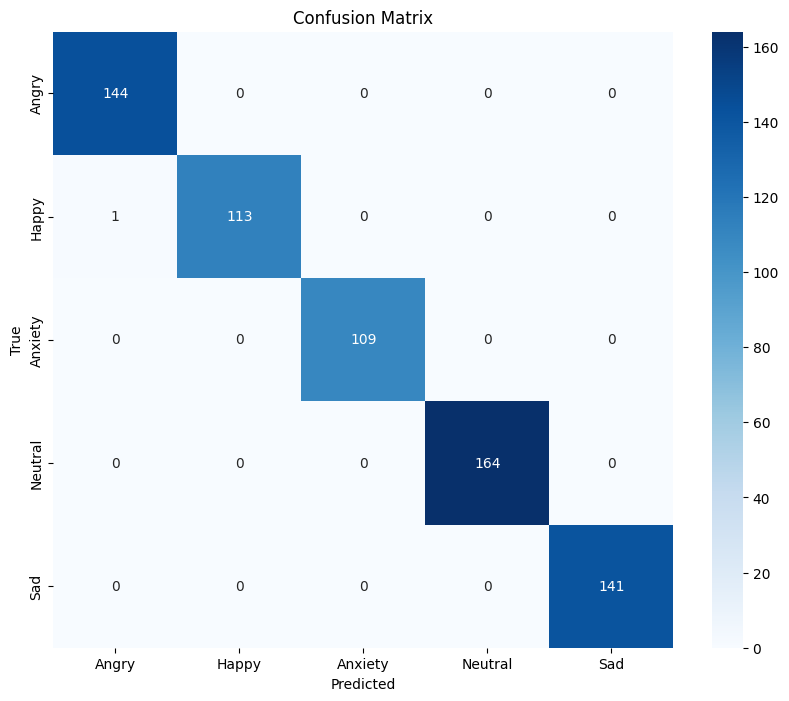


Classification Report:
              precision    recall  f1-score   support

       Angry       0.99      1.00      1.00       144
       Happy       1.00      0.99      1.00       114
     Anxiety       1.00      1.00      1.00       109
     Neutral       1.00      1.00      1.00       164
         Sad       1.00      1.00      1.00       141

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672


Evaluation metric formulas:
1. Precision = TP / (TP + FP)
   - TP (True Positives): Number of samples correctly predicted for a class.
   - FP (False Positives): Number of samples incorrectly predicted as that class.
2. Recall = TP / (TP + FN)
   - FN (False Negatives): Number of samples that belong to the class but were incorrectly predicted.
3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)


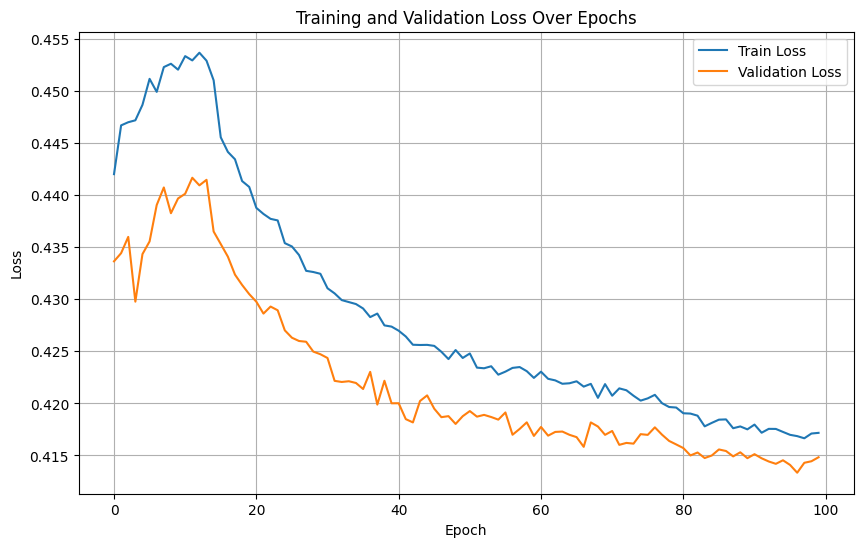

In [25]:
	
if __name__ == "__main__":
    # Path to the data
    root_folder = DATA_PATH
    folders = [f for f in glob(os.path.join(root_folder, "*")) if os.path.isdir(f)]
    all_files = []
    for folder in folders:
        files = glob(os.path.join(folder, "**", "*.wav"), recursive=True)
        all_files.extend(files)
        print(f"Found {len(files)} files in folder: {os.path.basename(folder)}")

    if not all_files:
        raise ValueError("No audio files found in the training directory.")

    # Calculate GLOBAL_PITCH_PARAMS first
    print("Calculating GLOBAL_PITCH_PARAMS from training data...")
    GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE = calculate_global_pitch_params(all_files)
    print(f"GLOBAL_MEAN_PITCH: {GLOBAL_MEAN_PITCH:.4f}, GLOBAL_JITTER: {GLOBAL_JITTER:.4f}, GLOBAL_PITCH_SLOPE: {GLOBAL_PITCH_SLOPE:.4f}")

    # Ensure y_raw_train has valid labels before computing class weights
    y_raw = []
    for f in all_files:
        folder_name = os.path.basename(os.path.dirname(f))
        if folder_name in emotion_map:
            y_raw.append(emotion_map[folder_name])
    
    y_raw_train = np.array(y_raw)

    if len(y_raw_train) == 0:
        raise ValueError("No valid emotion labels found for class weight calculation. Check your data and emotion_map.")

    print("Original label distribution:", Counter([EMOTIONS[i] for i in y_raw_train]))

    # Compute class weights
    # Ensure classes are passed correctly as np.unique(y_raw_train)
    class_weights = compute_class_weight('balanced', classes=np.unique(y_raw_train), y=y_raw_train)
    class_weight_dict = dict(enumerate(class_weights))
    print("Class weights:", class_weight_dict)

    # Prepare data
    X, y = prepare_training_data(all_files, emotion_map, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))
    print(f"X shape: {X.shape}")

    # Normalize features
    scaler = StandardScaler()
    original_shape = X.shape
    X_2d = X.reshape(original_shape[0], -1)
    X_2d = scaler.fit_transform(X_2d)
    X = X_2d.reshape(original_shape)

    calculated_input_dim0 = X.shape[1]
    cnn_input_shape = (calculated_input_dim0, X.shape[2], 1)
    print(f"Calculated CNN Input Shape: {cnn_input_shape}")
    
    # Build and train the model
    cnn_model = build_orionnet(input_shape=cnn_input_shape)
    cnn_model, history, X_test, y_test = train_and_evaluate_model(
        cnn_model, X, y,
        epochs=100,
        batch_size=16,
        checkpoint_path='best_cnn_2d_vesc.keras',
        class_weight=class_weight_dict,
        k_folds=5
    )
    joblib.dump(scaler, 'final_cnn_2d_vesc.pkl')
    # Save the final model
    cnn_model.save('final_cnn_2d_vesc.keras')
    evaluate_model(cnn_model, X_test, y_test)
    plot_loss_history(history)

Test Part

Found 37 files in folder: Angry
Found 32 files in folder: Neutral
Found 20 files in folder: Anxiety
Found 99 files in folder: Sad
Found 44 files in folder: Happy
Total test files: 232
Original label distribution (test): Counter({'Sad': 99, 'Happy': 44, 'Angry': 37, 'Neutral': 32, 'Anxiety': 20})
GLOBAL_MEAN_PITCH: 1314.3724, GLOBAL_JITTER: 1039.1417, GLOBAL_PITCH_SLOPE: 0.0000
Total number of test audio files: 232
Processed: 232 samples, skipped: 0 files.
Test dataset shape: X=(232, 107, 157, 1), y=(232, 5)

Sample prediction probabilities:
Sample 1: True=Angry, Pred=Angry, Prob=[0.92602813 0.02088161 0.01559123 0.02195645 0.01554265]
Sample 2: True=Angry, Pred=Angry, Prob=[0.88461316 0.03045385 0.02471401 0.02785529 0.03236362]
Sample 3: True=Angry, Pred=Angry, Prob=[0.83597285 0.0608111  0.05068987 0.0262191  0.02630704]
Sample 4: True=Angry, Pred=Angry, Prob=[0.93735874 0.01678927 0.01419522 0.01754443 0.01411236]
Sample 5: True=Angry, Pred=Angry, Prob=[0.93031925 0.01706456 0.01662

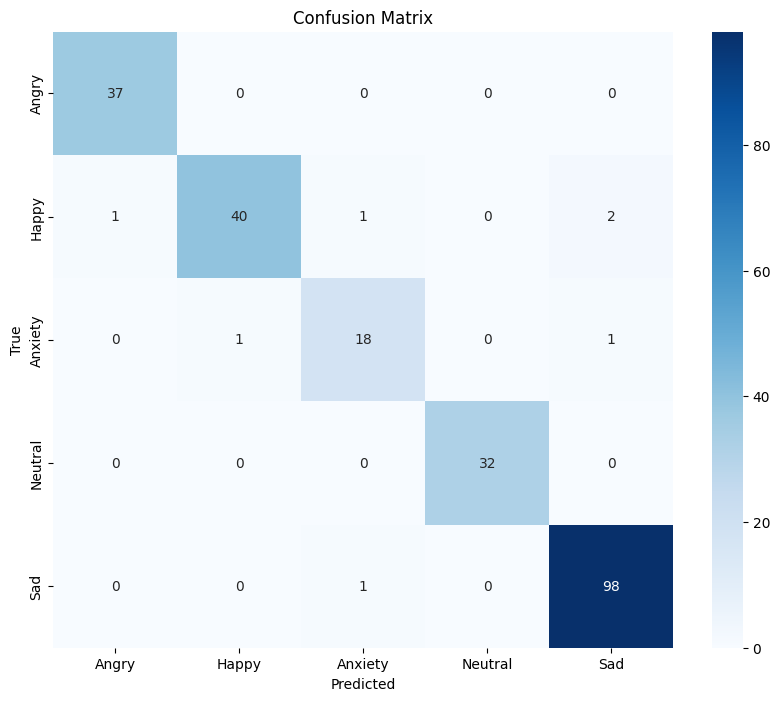


Classification Report:
              precision    recall  f1-score   support

       Angry       0.97      1.00      0.99        37
       Happy       0.98      0.91      0.94        44
     Anxiety       0.90      0.90      0.90        20
     Neutral       1.00      1.00      1.00        32
         Sad       0.97      0.99      0.98        99

    accuracy                           0.97       232
   macro avg       0.96      0.96      0.96       232
weighted avg       0.97      0.97      0.97       232


Evaluation metric formulas:
1. Precision = TP / (TP + FP)
   - TP (True Positives): Number of samples correctly predicted for a class.
   - FP (False Positives): Number of samples incorrectly predicted as that class.
2. Recall = TP / (TP + FN)
   - FN (False Negatives): Number of samples that belong to the class but were incorrectly predicted.
3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)

Predictions on test files:
Prediction probabilities for /kaggle/input/speech-

In [26]:
    #best_model = tf.keras.models.load_model('final_cnn_2d_vesc.keras')
    #best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    #                   loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    #                   metrics=['accuracy'])
    #scaler = joblib.load('final_cnn_2d_vesc.pkl')
    # Prepare test data
    root_folder_test = "/kaggle/input/speech-emotion-10/VESC_test/VESC_test"
    folders_test = [f for f in glob(os.path.join(root_folder_test, "*")) if os.path.isdir(f)]
    all_files_test = []
    for folder in folders_test:
        files = glob(os.path.join(folder, "**", "*.wav"), recursive=True)
        all_files_test.extend(files)
        print(f"Found {len(files)} files in folder: {os.path.basename(folder)}")

    if not all_files_test:
        raise ValueError("No audio files found in the test directory.")

    print(f"Total test files: {len(all_files_test)}")

    y_raw_test = [emotion_map.get(os.path.basename(os.path.dirname(f)), -1) for f in all_files_test]
    print("Original label distribution (test):", Counter([EMOTIONS[i] for i in y_raw_test if i != -1]))
    print(f"GLOBAL_MEAN_PITCH: {GLOBAL_MEAN_PITCH:.4f}, GLOBAL_JITTER: {GLOBAL_JITTER:.4f}, GLOBAL_PITCH_SLOPE: {GLOBAL_PITCH_SLOPE:.4f}")
    X_test, y_test = prepare_test_data(all_files_test, emotion_map, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))

    # Normalize features for the test set
    X_test_2d = X_test.reshape(X_test.shape[0], -1)
    X_test_2d = scaler.transform(X_test_2d)
    X_test = X_test_2d.reshape(X_test.shape)

    evaluate_model(cnn_model, X_test, y_test)

    print("\nPredictions on test files:")
    for test_path in all_files_test:
        predicted_emotion = predict_emotion(test_path, cnn_model, scaler, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))
        print(f"Predicted emotion for {os.path.basename(test_path)} (best model): {predicted_emotion}")